# HARQ Playground

This notebook mirrors the `hello_estimate.ipynb` pipeline while showcasing `Heterogenous_MovementLayout`, which separates logical patches into memory, compute, communication, and factory regions.

In [6]:
from collections import Counter
import cirq
import numpy as np
import warnings
import sys

sys.path.append("../")
import resource_estimation as res

warnings.filterwarnings("ignore", category=FutureWarning)

## Input Circuit

The circuit is built from standard one- and two-qubit gates so it can be compiled into the Clifford + Rz and Clifford + T pipeline.

In [7]:
num_qubits = 3
depth = 2
rng = np.random.default_rng(7)

qubits = cirq.LineQubit.range(num_qubits)
circuit = cirq.Circuit()
for layer in range(depth):
    circuit.append(cirq.H.on_each(*qubits))
    circuit.append(cirq.rz(float(rng.uniform(-np.pi, np.pi))).on(q) for q in qubits)
    start = layer % 2
    circuit.append(cirq.CNOT(qubits[i], qubits[i + 1]) for i in range(start, num_qubits - 1, 2))

circuit

0: ───H───Rz(0.25π)────@───H────────────Rz(-0.55π)───────
                       │
1: ───H───Rz(0.794π)───X───H────────────Rz(-0.4π)────@───
                                                     │
2: ───H───Rz(0.551π)───H───Rz(0.747π)────────────────X───

## Compile to Clifford + T

In [8]:
cliff_rz_circuit = res.cliff_rz.compile_cliff_rz(circuit)
grouped_ops = Counter(
    str(op.gate) if op.gate not in cirq.GateFamily(cirq.Rz) else "Rz"
    for op in cliff_rz_circuit.all_operations()
)
eps = 1 - 0.99 ** (1 / grouped_ops["Rz"])
synthesized_circuit = res.clifford_t.compile_cirq_to_clifford_t(
    cliff_rz_circuit,
    eps=eps,
    verbose=False,
)
print(f"Clifford + Rz moments: {len(cliff_rz_circuit)}")
print(f"Clifford + T moments: {len(synthesized_circuit)}")
print(grouped_ops)

Clifford + Rz moments: 6
Clifford + T moments: 240
Counter({'H': 6, 'Rz': 6, 'CNOT': 2})


## Heterogenous Movement Layout

Logical qubits start in memory. Each operation is moved into a small compute region, executed there, and moved back to memory. The communication region is shown as a pathway between memory and compute.

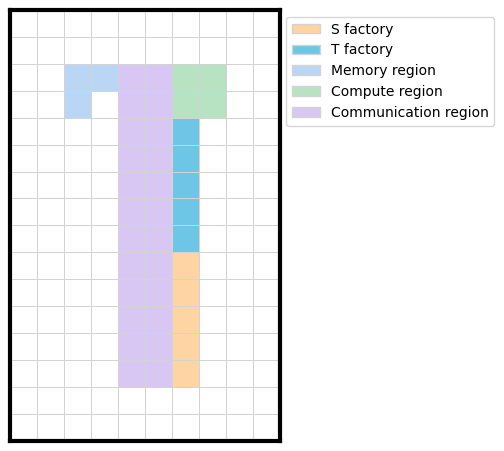

In [9]:
layout = res.layout.Heterogenous_MovementLayout(
    input_circuit=synthesized_circuit,
    num_t_factories=5,
    num_s_factories=5,
    compute_capacity=4,
)
layout.visualize_layout()

## FT Compile and Estimate

In [10]:
arch = res.architecture.DefaultMovement(
    d=11,
    idling=False,
    post_op_correction=True,
    syndrome_rounds=1, 
    cultivation_repetition=5,
    communication_move_factor=3.0,
)
primitive_circuit = res.compile_ftqc.ft_compile(layout=layout, arc=arch, verbose=False)
estimator = res.estimate.ResourceEstimator(arc=arch)
gate_cost = estimator.parallel_circuit_cost(primitive_circuit, pretty=True)
circuit_time = estimator.parallel_circuit_time(primitive_circuit)
physical_qubits = estimator.physical_qubits(primitive_circuit)

In [11]:
print("Gates")
for op, count in sorted(gate_cost.items(), key=lambda x: x[1], reverse=True):
    print(f"{op}{' ' * max(1, 25 - len(op))}{count:.2e}")
print("*" * 33)
print("Metrics")
print(f"Time (μs){' ' * 16}{circuit_time:.2e}")
print(f"Qubits{' ' * 19}{physical_qubits:.2e}")
print("*" * 33)

Gates
QubitPermutationGate     4.84e+04
CZ                       2.11e+04
PhasedXZGate             5.88e+03
ResetChannel             2.77e+03
MeasurementGate          2.61e+03
*********************************
Metrics
Time (μs)                2.75e+07
Qubits                   9.88e+03
*********************************


In [12]:
serial_counts = estimator.serial_circuit_cost(primitive_circuit, pretty=False)
serial_time = sum(
    count * arch.phys_gate_times[gate]
    for gate, count in serial_counts.items()
)

parallel_time = estimator.parallel_circuit_time(primitive_circuit)

In [13]:
print(f"Parallel critical-path time (μs): {parallel_time:.6e}")
print(f"Serial total-operation time (μs): {serial_time:.6e}")
print(f"QubitPermutationGate count: {serial_counts.get(cirq.QubitPermutationGate, 0):.0f}")

Parallel critical-path time (μs): 2.745784e+07
Serial total-operation time (μs): 2.147908e+09
QubitPermutationGate count: 254139
